# Data Importation and Preprocessing


In [1]:
# ============================================================
# NHANES Diabetes Prediction Project
# DATA CLEANING + FEATURE ENGINEERING + PREPROCESSING
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import os
from functools import reduce

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

from collections import defaultdict

# ============================================================
# RESULTS COLLECTOR
# ============================================================

summary_store = defaultdict(lambda: defaultdict(list))

def store_results(dataset_label, model_type, cv_auc, y_true, y_probs, y_preds):
    """
    Call this at the end of each seed loop to store metrics.
    dataset_label : "Full", "Pre-COVID", or "COVID"
    model_type    : "LR" or "SVM"
    """
    key = (dataset_label, model_type)
    summary_store[key]["cv_roc_auc"].append(cv_auc)
    summary_store[key]["accuracy"].append(accuracy_score(y_true, y_preds))
    summary_store[key]["roc_auc"].append(roc_auc_score(y_true, y_probs))
    summary_store[key]["f1"].append(f1_score(y_true, y_preds))
    summary_store[key]["recall"].append(recall_score(y_true, y_preds))
    summary_store[key]["precision"].append(precision_score(y_true, y_preds, zero_division=0))

# ============================================================
# 2. FILE PATHS *CHANGE AS NEEDED
# ============================================================

dir_17_20 = r"C:\Users\Malik\Desktop\Module_5_proj\2017-2020_Data"
dir_21_23 = r"C:\Users\Malik\Desktop\Module_5_proj\2021-2023_Data"

# ============================================================
# 3. FEATURE MAP
# ============================================================

feature_map = {

    # --------------------------------------------------------
    # DEMOGRAPHICS
    # --------------------------------------------------------
    "DEMO": [
        "SEQN",          #Participant ID
        "RIAGENDR",        # Gender  
        "RIDAGEYR",       # Age
        "RIDRETH3",       # Race/ethnicity
        "DMDEDUC2",       # Education
        "INDFMPIR",       # Income-to-poverty ratio
        "DMDBORN4",       # Country of birth
        "DMDMARTZ",       # Marital status
        "DDSRVYR",        # Survey cycle
        "DMDYRUSR",       # Years in US
        "DMDYRUSZ"
    ],

    # --------------------------------------------------------
    # BODY MEASURES
    # --------------------------------------------------------
    "BMX": [
        "SEQN",
        "BMXWT",          # Weight
        "BMXHT",          # Height
        "BMXBMI",         # BMI
        "BMXWAIST",       # Waist circumference
        "BMXARMC",        # Arm circumference
        "BMXARML",        # Upper arm length
        "BMXLEG",         # Upper leg length
        "BMXHIP",         # Hip circumference
    ],

    # --------------------------------------------------------
    # BLOOD PRESSURE
    # --------------------------------------------------------
    "BPXO": [
        "SEQN",

        # Systolic BP readings
        "BPXOSY1",
        "BPXOSY2",
        "BPXOSY3",

        # Diastolic BP readings
        "BPXODI1",
        "BPXODI2",
        "BPXODI3",

        # Pulse readings
        "BPXOPLS1",
        "BPXOPLS2",
        "BPXOPLS3"
    ],

    # --------------------------------------------------------
    # GLYCOHEMOGLOBIN
    # --------------------------------------------------------
    "GHB": [
        "SEQN",
        "LBXGH"           # HbA1c
    ],


    # --------------------------------------------------------
    # BIOCHEMISTRY
    # --------------------------------------------------------
    "BIOPRO": [
        "SEQN",

        "LBXSCR",         # Creatinine
        "LBXSBU",         # BUN
        "LBXSNASI",       # Sodium
        "LBXSKSI",        # Potassium
        "LBXSCLSI",       # Chloride
        "LBXSC3SI",       # Bicarbonate
        "LBXSPH",         # Phosphorus
        "LBXSAL",         # Albumin
        "LBXSTP",         # Total protein
        "LBXSGB",         # Globulin
        "LBXSTB",         # Bilirubin
        "LBXSCA",         # Calcium
        "LBXSIR",         # Iron
        "LBXSOSSI",       # Osmolality
        "LBXSLDSI"        # LDH
    ],

    # --------------------------------------------------------
    # TRIGLYCERIDES
    # --------------------------------------------------------
    "TRIGLY": [
        "SEQN",
        "LBXTR",
        "LBXTLG" 
    ],

    # --------------------------------------------------------
    # COMPLETE BLOOD COUNT
    # --------------------------------------------------------
    "CBC": [
        "SEQN",

        "LBXWBCSI",       # White blood cells
        "LBXRDW",         # RDW
        "LBXPLTSI",       # Platelets
        "LBXMPSI",        # MPV
        "LBDNENO",        # Neutrophils
        "LBDLYMNO",       # Lymphocytes
    
    ],

    # --------------------------------------------------------
    # INFLAMMATION
    # --------------------------------------------------------
    "HSCRP": [
        "SEQN",
        "LBXHSCRP"
    ]
}


# ============================================================
# 3. FILE LISTS
# ============================================================

files_17_20 = [
    "P_DEMO.xpt",
    "P_BMX.xpt",
    "P_BPXO.xpt",
    "P_GHB.xpt",
    "P_BIOPRO.xpt",
    "P_TRIGLY.xpt",
    "P_CBC.xpt",
    "P_HSCRP.xpt"
]

files_21_23 = [
    "DEMO_L.xpt",
    "BMX_L.xpt",
    "BPXO_L.xpt",
    "GHB_L.xpt",
    "BIOPRO_L.xpt",
    "TRIGLY_L.xpt",
    "CBC_L.xpt",
    "HSCRP_L.xpt"
]


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

import re

def extract_key(filename):
    """
    Cleaner extraction using regex to only strip 
    NHANES prefixes (P_) and suffixes (_L).
    """
    # 1. Remove file extension
    name = filename.split('.')[0].upper()
    
    # 2. Remove 'P_' only if it's at the START
    name = re.sub(r'^P_', '', name)
    
    # 3. Remove '_L' only if it's at the END
    name = re.sub(r'_L$', '', name)
    
    return name


def load_cycle(file_list, folder):
    """
    Loads all NHANES files for a given survey cycle 
    with verbose error messaging.
    """
    dfs = []
    print(f"\n--- Starting Load for Folder: {folder} ---")

    for file in file_list:
        path = os.path.join(folder, file)
        
        # 1. Check if file exists on disk
        if not os.path.exists(path):
            print(f"❌ FILE NOT FOUND: {file} at {path}")
            continue

        # 2. Check Key Extraction
        key = extract_key(file)
        if key not in feature_map:
            print(f"⚠️  KEY SKIPPED: '{key}' (extracted from {file}) is not in feature_map.")
            continue

        try:
            # 3. Try reading the file
            df = pd.read_sas(path, format="xport")
            
            # 4. Check for Column Mismatch
            target_cols = feature_map[key]
            cols_in_df = [c for c in target_cols if c in df.columns]
            missing_cols = set(target_cols) - set(df.columns)

            if "SEQN" not in df.columns:
                print(f"❌ MERGE ERROR: {file} is missing 'SEQN' column.")
                continue

            if not cols_in_df or len(cols_in_df) <= 1: # Only SEQN found
                print(f"⚠️  DATA WARNING: {file} loaded, but found no features except SEQN. Missing: {missing_cols}")
            
            print(f"✅ SUCCESS: Loaded {file} ({len(df)} rows, {len(cols_in_df)} features matched).")
            dfs.append(df[cols_in_df])

        except Exception as e:
            print(f"🔥 CRITICAL ERROR reading {file}: {e}")

    if not dfs:
        print("🚨 RESULT: No dataframes were collected!")
        return pd.DataFrame()

    # Merge logic
    merged_df = reduce(
        lambda left, right: pd.merge(left, right, on="SEQN", how="outer"),
        dfs
    )
    
    print(f"🏁 FINISHED: Final merged shape: {merged_df.shape}")
    return merged_df

# ============================================================
# 5. LOAD BOTH NHANES CYCLES
# ============================================================

df_17_20 = load_cycle(files_17_20, dir_17_20)
df_21_23 = load_cycle(files_21_23, dir_21_23)

df_17_20 = df_17_20.rename(columns={'DMDYRUSZ': 'DMDYRUSR'})
df_21_23 = df_21_23.rename(columns={'LBXTLG': 'LBXTR'})
# Add cycle labels
df_17_20["cycle"] = "2017-2020"
df_21_23["cycle"] = "2021-2023"

# Combine datasets
final_df = pd.concat(
    [df_17_20, df_21_23],
    ignore_index=True
)


# ============================================================
# 6. RENAME VARIABLES
# ============================================================

rename_dict = {

    # --------------------------------------------------------
    # DEMOGRAPHICS
    # --------------------------------------------------------
    "RIAGENDR": "gender",
    "RIDAGEYR": "age",
    "RIDRETH3": "race_ethnicity",
    "DMDEDUC2": "education",
    "INDFMPIR": "income_poverty_ratio",
    "DMDBORN4": "birth_country",
    "DMDMARTZ": "marital_status",

    # --------------------------------------------------------
    # BODY MEASURES
    # --------------------------------------------------------
    "BMXWT": "weight_kg",
    "BMXHT": "height_cm",
    "BMXBMI": "bmi",
    "BMXWAIST": "waist_cm",
    "BMXHIP": "hip_cm",
    "BMXARMC": "arm_circumference",
    "BMXARML": "upper_arm_length",
    "BMXLEG": "upper_leg_length",

    # --------------------------------------------------------
    # BLOOD PRESSURE
    # --------------------------------------------------------
    "BPXOSY1": "sys_bp_1",
    "BPXOSY2": "sys_bp_2",
    "BPXOSY3": "sys_bp_3",

    "BPXODI1": "dia_bp_1",
    "BPXODI2": "dia_bp_2",
    "BPXODI3": "dia_bp_3",

    "BPXOPLS1": "pulse_1",
    "BPXOPLS2": "pulse_2",
    "BPXOPLS3": "pulse_3",

    # --------------------------------------------------------
    # LABS
    # --------------------------------------------------------
    "LBXGH": "hba1c",

    "LBXSCR": "creatinine",
    "LBXSBU": "bun",
    "LBXSNASI": "sodium",
    "LBXSKSI": "potassium",
    "LBXSCLSI": "chloride",
    "LBXSC3SI": "bicarbonate",
    "LBXSPH": "phosphorus",
    "LBXSAL": "albumin",
    "LBXSTP": "total_protein",
    "LBXSGB": "globulin",
    "LBXSTB": "bilirubin",
    "LBXSCA": "calcium",
    "LBXSIR": "iron",
    "LBXSOSSI": "osmolality",
    "LBXSLDSI": "ldh",

    # --------------------------------------------------------
    # CBC
    # --------------------------------------------------------
    "LBXWBCSI": "wbc",
    "LBXRDW": "rdw",
    "LBXPLTSI": "platelets",
    "LBXMPSI": "mpv",
    "LBDNENO": "neutrophils",
    "LBDLYMNO": "lymphocytes"
}

final_df = final_df.rename(columns=rename_dict)



# CHECKING MIN MAX OF FEATURES:
# 1. Select only numeric columns
#numeric_df = final_df.select_dtypes(include=[np.number])

# 2. Calculate Min and Max for all numeric columns
#summary_stats = numeric_df.agg(['min', 'max']).T

# 3. Format the output for better readability
#print("--- Value Ranges for All Numeric Columns ---")
#with pd.option_context('display.max_rows', None, 'display.float_format', '{:.2f}'.format):
#    print(summary_stats)

# 4. Optional: Check for columns with suspiciously low minimums (like 0)
#zeros_detected = summary_stats[summary_stats['min'] == 0].index.tolist()
#if zeros_detected:
#    print(f"\n⚠️  Columns containing 0.0 (check if these are placeholders): {zeros_detected}")
# ============================================================
# 7. KEEP ONLY ROWS WITH HBA1C
# ============================================================
# HbA1c is needed to create diabetes target variable.

final_df = final_df[
    final_df["hba1c"].notna()
].copy()


# ============================================================
# 8. REMOVE HIGH-MISSINGNESS COLUMNS
# ============================================================

missing_threshold = 0.40

# Calculate the ratio of missing values for each column
missing_ratio = final_df.isnull().mean()

# Identify columns exceeding the threshold
cols_to_drop = missing_ratio[missing_ratio >= missing_threshold].index

# --- NEW: Informative Error/Status Messages ---
print(f"--- Missingness Threshold Check (>{missing_threshold*100}%) ---")
if len(cols_to_drop) > 0:
    print(f"Dropped {len(cols_to_drop)} columns due to high missingness:")
    for col in cols_to_drop:
        print(f"  - {col}: {missing_ratio[col]:.2%} missing")
else:
    print("No columns exceeded the missingness threshold.")

# Perform the drop
final_df = final_df.drop(columns=cols_to_drop)
print(f"Remaining columns: {len(final_df.columns)}")
# -----------------------------------------------
# 9. FEATURE ENGINEERING
# ============================================================

df = final_df.copy()


# ------------------------------------------------------------
# BODY COMPOSITION FEATURES
# ------------------------------------------------------------
df["waist_height_ratio"] = df["waist_cm"] / df["height_cm"]
df["waist_hip_ratio"] = df["waist_cm"] / df["hip_cm"]

# BMI category (WHO — sex-neutral for adults)
df["bmi_category"] = np.select(
    [
        df["bmi"] < 18.5,
        (df["bmi"] >= 18.5) & (df["bmi"] < 25),
        (df["bmi"] >= 25) & (df["bmi"] < 30),
        df["bmi"] >= 30
    ],
    [
        "underweight",
        "normal",
        "overweight",
        "obese"
    ],
    default=np.nan
)

# Central obesity — IDF sex-stratified thresholds
# Male (RIAGENDR == 1): waist > 94 cm
# Female (RIAGENDR == 2): waist > 80 cm
df["central_obesity"] = np.where(
    df["gender"] == 1,
    (df["waist_cm"] > 94).astype(int),
    np.where(
        df["gender"] == 2,
        (df["waist_cm"] > 80).astype(int),
        np.nan  # missing gender → missing flag
    )
)

# ------------------------------------------------------------
# BLOOD PRESSURE FEATURES
# ------------------------------------------------------------

df["mean_sys_bp"] = df[
    ["sys_bp_1", "sys_bp_2", "sys_bp_3"]
].mean(axis=1)

df["mean_dia_bp"] = df[
    ["dia_bp_1", "dia_bp_2", "dia_bp_3"]
].mean(axis=1)

# Variability between BP measurements
df["sys_bp_std"] = df[
    ["sys_bp_1", "sys_bp_2", "sys_bp_3"]
].std(axis=1)

df["dia_bp_std"] = df[
    ["dia_bp_1", "dia_bp_2", "dia_bp_3"]
].std(axis=1)

# Hypertension indicator
df["hypertension_flag"] = (
    (df["mean_sys_bp"] >= 130) |
    (df["mean_dia_bp"] >= 80)
).astype(int)


# ------------------------------------------------------------
# PULSE FEATURES
# ------------------------------------------------------------

df["mean_pulse"] = df[
    ["pulse_1", "pulse_2", "pulse_3"]
].mean(axis=1)

df["pulse_std"] = df[
    ["pulse_1", "pulse_2", "pulse_3"]
].std(axis=1)


# INFLAMMATION FEATURES
# ------------------------------------------------------------

df["neutrophil_lymph_ratio"] = (
    df["neutrophils"] / df["lymphocytes"]
)

# ============================================================
# 10. TARGET VARIABLES
# ============================================================

# Diabetes classification using ADA threshold
df["diabetes_status"] = (
    df["hba1c"] >= 6.5
).astype(int)

# COVID-era indicator
df["covid_era"] = (
    df["cycle"] == "2021-2023"
).astype(int)


# ============================================================
# 11. CLEAN CATEGORICAL VARIABLES
# ============================================================

# ------------------------------------------------------------
# Race/Ethnicity Mapping
# ------------------------------------------------------------

race_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other Race / Multi-Racial"
}

df["race_ethnicity"] = (
    df["race_ethnicity"]
    .map(race_map)
)


# ------------------------------------------------------------
# Birth Country Cleaning
# ------------------------------------------------------------

# Remove refused/don't know
df["birth_country"] = df["birth_country"].replace({
    77: np.nan,
    99: np.nan
})

birth_map = {
    1: "US Born",
    2: "Foreign Born"
}

df["birth_country"] = (
    df["birth_country"]
    .map(birth_map)
)


# ------------------------------------------------------------
# Education Cleaning
# ------------------------------------------------------------

df["education"] = df["education"].replace({
    7: np.nan,
    9: np.nan
})

education_map = {
    1: "Less than 9th Grade",
    2: "9-11th Grade",
    3: "High School/GED",
    4: "Some College/AA",
    5: "College Graduate+"
}

df["education"] = (
    df["education"]
    .map(education_map)
)


# ------------------------------------------------------------
# Marital Status Cleaning
# ------------------------------------------------------------

df["marital_status"] = df["marital_status"].replace({
    77: np.nan,
    99: np.nan
})

marital_map = {
    1: "Married/Partner",
    2: "Widowed/Divorced/Separated",
    3: "Never Married"
}

df["marital_status"] = (
    df["marital_status"]
    .map(marital_map)
)


# ------------------------------------------------------------
# Convert categorical columns to category dtype
# ------------------------------------------------------------

categorical_cols = [
    "race_ethnicity",
    "education",
    "birth_country",
    "marital_status",
    "bmi_category"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")


# ============================================================
# 12. CLEAN EXTREME VALUES
# ============================================================

# Replace impossible income values with NaN
df.loc[
    df["income_poverty_ratio"] < 0.01,
    "income_poverty_ratio"
] = np.nan

# Cap extreme laboratory values
df["wbc"] = df["wbc"].clip(upper=50)
df["lymphocytes"] = df["lymphocytes"].clip(upper=20)
df["platelets"] = df["platelets"].clip(upper=700)
df["creatinine"] = df["creatinine"].clip(upper=10)

# Replace string "nan" with actual NaN
df["bmi_category"] = df["bmi_category"].replace(
    "nan",
    np.nan
)


# ============================================================
# 13. DROP UNUSED COLUMNS
# ============================================================

drop_cols = [

    # Raw body measures
    "weight_kg",
    "height_cm",
    "waist_cm",
    "hip_cm",
    "arm_circumference",
    "upper_arm_length",
    "upper_leg_length",
    "bmi",

    # Raw blood pressure
    "sys_bp_1",
    "sys_bp_2",
    "sys_bp_3",
    "dia_bp_1",
    "dia_bp_2",
    "dia_bp_3",

    # Raw pulse
    "pulse_1",
    "pulse_2",
    "pulse_3",

    # Target leakage
    "hba1c",

    # Metadata
    "cycle",
    "SEQN"
]

df = df.drop(columns=drop_cols)

# ============================================================
# 17. FINAL DATASET CHECK
# ============================================================

print("Final dataset shape:", df.shape)

print("\nMissingness:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nData types:")
print(df.dtypes)


--- Starting Load for Folder: C:\Users\Malik\Desktop\Module_5_proj\2017-2020_Data ---
✅ SUCCESS: Loaded P_DEMO.xpt (15560 rows, 9 features matched).
✅ SUCCESS: Loaded P_BMX.xpt (14300 rows, 9 features matched).
✅ SUCCESS: Loaded P_BPXO.xpt (11656 rows, 10 features matched).
✅ SUCCESS: Loaded P_GHB.xpt (10409 rows, 2 features matched).
✅ SUCCESS: Loaded P_BIOPRO.xpt (10409 rows, 16 features matched).
✅ SUCCESS: Loaded P_TRIGLY.xpt (5090 rows, 2 features matched).
✅ SUCCESS: Loaded P_CBC.xpt (13772 rows, 7 features matched).
✅ SUCCESS: Loaded P_HSCRP.xpt (13772 rows, 2 features matched).
🏁 FINISHED: Final merged shape: (15560, 50)

--- Starting Load for Folder: C:\Users\Malik\Desktop\Module_5_proj\2021-2023_Data ---
✅ SUCCESS: Loaded DEMO_L.xpt (11933 rows, 9 features matched).
✅ SUCCESS: Loaded BMX_L.xpt (8860 rows, 9 features matched).
✅ SUCCESS: Loaded BPXO_L.xpt (7801 rows, 10 features matched).
✅ SUCCESS: Loaded GHB_L.xpt (7199 rows, 2 features matched).
✅ SUCCESS: Loaded BIOPRO_L.

# Data Exploration

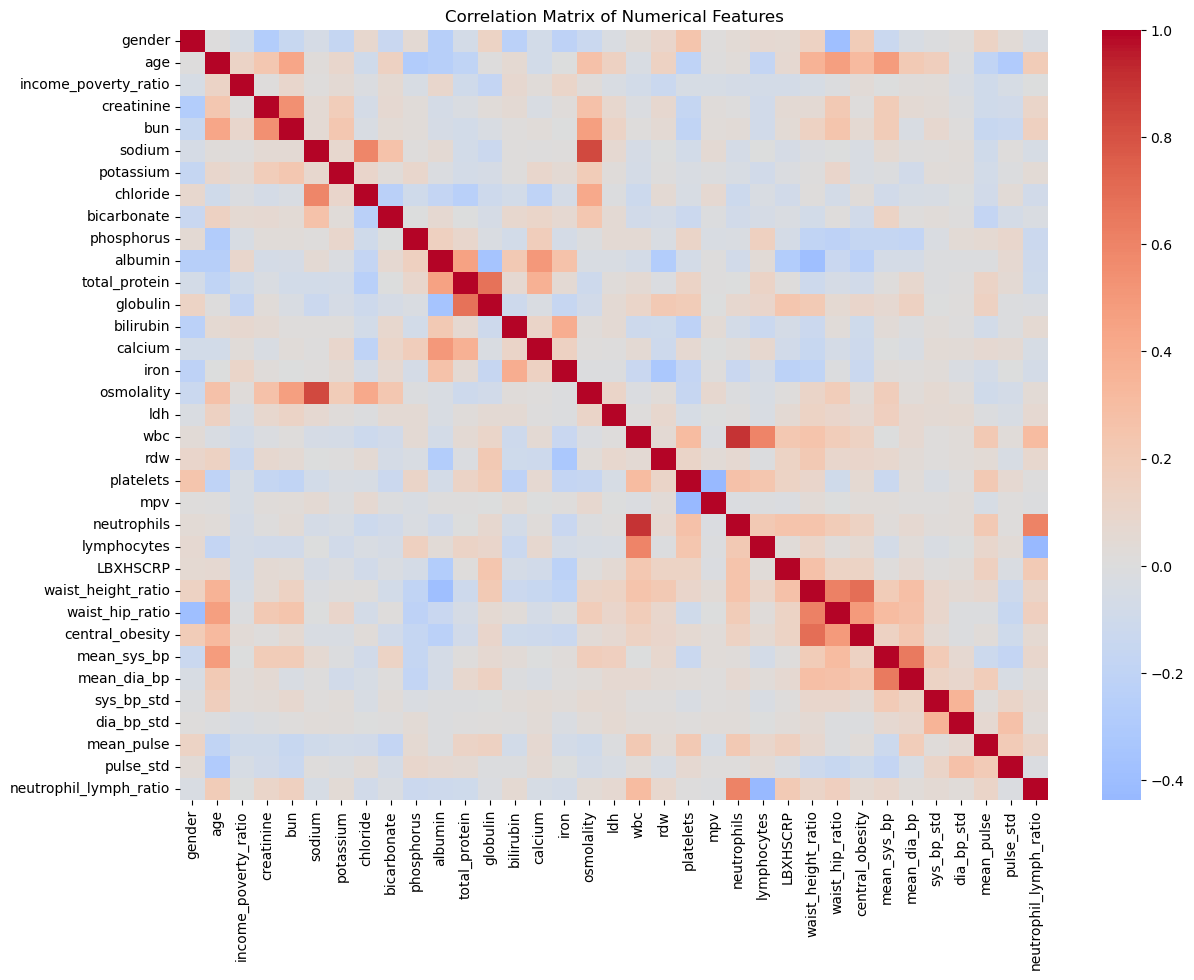

In [2]:
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [3]:
# choose features (exclude target)
X_vif = df.drop(columns=["diabetes_status", "covid_era"])

# keep only numeric columns
X_vif = X_vif.select_dtypes(include=[np.number])

# drop rows with NaNs (VIF cannot handle missing values)
X_vif = X_vif.dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)

print(vif_data)

def compute_vif(df):
    vif = pd.DataFrame()
    vif["feature"] = df.columns
    vif["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    return vif.sort_values("VIF", ascending=False)


X_temp = X_vif.copy()

while True:
    vif_df = compute_vif(X_temp)
    
    max_vif = vif_df["VIF"].max()
    
    if max_vif > 10:
        drop_feature = vif_df.iloc[0]["feature"]
        print(f"Dropping {drop_feature} with VIF: {max_vif}")
        X_temp = X_temp.drop(columns=[drop_feature])
    else:
        break

final_vif = compute_vif(X_temp)
print(final_vif)

C:\Users\Malik\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                   feature           VIF
11           total_protein           inf
12                globulin           inf
10                 albumin           inf
5                   sodium  3.038670e+04
16              osmolality  2.626320e+04
7                 chloride  3.425323e+03
14                 calcium  8.682263e+02
18                     wbc  4.849780e+02
26         waist_hip_ratio  3.518309e+02
22             neutrophils  1.964528e+02
8              bicarbonate  1.770636e+02
6                potassium  1.742888e+02
28             mean_sys_bp  1.490127e+02
19                     rdw  1.291078e+02
21                     mpv  1.135468e+02
29             mean_dia_bp  1.071637e+02
25      waist_height_ratio  9.657468e+01
23             lymphocytes  9.214740e+01
9               phosphorus  5.131243e+01
33              mean_pulse  5.027676e+01
20               platelets  2.809664e+01
4                      bun  2.505328e+01
17                     ldh  2.319154e+01
0               

C:\Users\Malik\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping total_protein with VIF: inf
Dropping sodium with VIF: 30386.69926996645
Dropping osmolality with VIF: 5222.0428437142855
Dropping calcium with VIF: 849.4693007061832
Dropping chloride with VIF: 639.9780417540668
Dropping wbc with VIF: 482.9201754039905
Dropping waist_hip_ratio with VIF: 308.0946477369879
Dropping albumin with VIF: 161.21133109195765
Dropping potassium with VIF: 137.79852801333985
Dropping mean_sys_bp with VIF: 136.47090427420892
Dropping rdw with VIF: 111.8354200121222
Dropping bicarbonate with VIF: 89.13053105346974
Dropping mean_dia_bp with VIF: 77.58074551730016
Dropping mpv with VIF: 70.14779323016391
Dropping waist_height_ratio with VIF: 62.01160722163889
Dropping globulin with VIF: 49.383506165179114
Dropping phosphorus with VIF: 36.978848160380345
Dropping mean_pulse with VIF: 32.61947952810879
Dropping neutrophils with VIF: 23.130736406690012
Dropping ldh with VIF: 18.38062321181523
Dropping platelets with VIF: 16.080710197920727
Dropping bun with VIF:

In [4]:
df = df.drop(columns=[
    "sodium",
    "chloride",
    "osmolality",
    "potassium",
    "calcium",
    "bicarbonate",
    "wbc",
    "neutrophils",
    "lymphocytes",
    "rdw",
    "mpv",
    "total_protein"
                ])

In [5]:
df.columns

Index(['gender', 'age', 'race_ethnicity', 'education', 'income_poverty_ratio',
       'birth_country', 'marital_status', 'creatinine', 'bun', 'phosphorus',
       'albumin', 'globulin', 'bilirubin', 'iron', 'ldh', 'platelets',
       'LBXHSCRP', 'waist_height_ratio', 'waist_hip_ratio', 'bmi_category',
       'central_obesity', 'mean_sys_bp', 'mean_dia_bp', 'sys_bp_std',
       'dia_bp_std', 'hypertension_flag', 'mean_pulse', 'pulse_std',
       'neutrophil_lymph_ratio', 'diabetes_status', 'covid_era'],
      dtype='str')

In [6]:
numeric_cols = df.select_dtypes(include=['number']).columns

# Calculate skewness for every numeric column
skew_results = df[numeric_cols].skew().sort_values(ascending=False)

# Create a summary dataframe
audit_df = pd.DataFrame({
    'Skewness': skew_results,
    'Imputation_Logic': skew_results.apply(lambda x: 'Median (Skewed)' if abs(x) > 0.5 else 'Mean (Symmetric)')
})

# Display the top 10 most skewed features
print("--- Top 20 Skewed Features ---")
print(audit_df.head(20))

# Check specific features you mentioned in your draft
important_features = ['LBXTR', 'LBXSCR', 'RIDAGEYR', 'BMXBMI'] # Triglycerides, Creatinine, Age, BMI
print("\n--- Targeted Feature Audit ---")
print(audit_df.loc[audit_df.index.isin(important_features)])

--- Top 20 Skewed Features ---
                         Skewness  Imputation_Logic
creatinine              11.623955   Median (Skewed)
LBXHSCRP                10.274902   Median (Skewed)
neutrophil_lymph_ratio   4.787277   Median (Skewed)
dia_bp_std               3.832597   Median (Skewed)
bilirubin                3.445273   Median (Skewed)
pulse_std                2.833267   Median (Skewed)
sys_bp_std               2.821635   Median (Skewed)
ldh                      2.794839   Median (Skewed)
bun                      2.465858   Median (Skewed)
diabetes_status          2.403570   Median (Skewed)
iron                     1.001463   Median (Skewed)
mean_sys_bp              0.964368   Median (Skewed)
platelets                0.816979   Median (Skewed)
globulin                 0.663685   Median (Skewed)
hypertension_flag        0.659537   Median (Skewed)
phosphorus               0.655421   Median (Skewed)
mean_dia_bp              0.511538   Median (Skewed)
mean_pulse               0.501653

# Pipeline

In [7]:
# ============================================================
# LOGISTIC REGRESSION PIPELINE
# ============================================================

# ============================================================
# DATA + SEEDS
# ============================================================

X = df.drop(columns=["diabetes_status", "covid_era"])
y = df["diabetes_status"]

random_seed_vals = [42, 76, 67, 21, 13]

# ============================================================
# LOOP OVER SEEDS
# ============================================================

for seed in random_seed_vals:

    # --------------------------------------------------------
    # SPLIT DATA
    # --------------------------------------------------------
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y,
        test_size=0.15,
        random_state=seed,
        stratify=y
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=0.1765,
        random_state=seed,
        stratify=y_train_full
    )

    # --------------------------------------------------------
    # COLUMN TYPES
    # --------------------------------------------------------
    numeric_cols = X_train.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols = X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # --------------------------------------------------------
    # PREPROCESSING
    # --------------------------------------------------------
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------
    log_reg = LogisticRegression(
        max_iter=3000,
        solver="saga",
        class_weight="balanced",
    )

    log_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", log_reg)
    ])

    # --------------------------------------------------------
    # HYPERPARAMETER GRID
    # --------------------------------------------------------
    param_grid_log = {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__penalty": ["l1", "l2"],
       
    }

    # --------------------------------------------------------
    # CROSS VALIDATION
    # --------------------------------------------------------
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    grid_search_log = GridSearchCV(
        estimator=log_model,
        param_grid=param_grid_log,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------
    grid_search_log.fit(X_train, y_train)

    best_log_model = grid_search_log.best_estimator_
    # Note: Remove the extra space from your original string so you don't get a double space
    print("Random Seed:", seed)
    print("Best Parameters:")
    print(grid_search_log.best_params_)

    print("\nBest CV ROC-AUC:")
    print(grid_search_log.best_score_)

    # --------------------------------------------------------
    # THRESHOLD TUNING
    # --------------------------------------------------------
    # ── Threshold Tuning ─────────────────────────────────────
    val_prob_log  = best_log_model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(val_prob_log.min(), val_prob_log.max(), 200)
    target_recall = 0.82
    best_t_log    = 0.5
    best_prec_log = 0
    for t in thresholds:
        preds     = (val_prob_log >= t).astype(int)
        recall    = recall_score(y_val, preds)
        precision = precision_score(y_val, preds, zero_division=0)
        if recall >= target_recall and precision > best_prec_log:
            best_prec_log = precision
            best_t_log    = t
    print(f"\nTarget Recall:          {target_recall}")
    print(f"Selected Threshold:     {best_t_log:.4f}")
    print(f"Precision at Threshold: {best_prec_log:.4f}")

    # --------------------------------------------------------
    # FINAL TEST EVALUATION
    # --------------------------------------------------------
    test_prob_log = best_log_model.predict_proba(X_test)[:, 1]

    test_pred_log = (test_prob_log >= best_t_log).astype(int)

    print("\nAccuracy:")
    print(accuracy_score(y_test, test_pred_log))

    print("\nROC-AUC:")
    print(roc_auc_score(y_test, test_prob_log))

    print("\nF1 Score:")
    print(f1_score(y_test, test_pred_log))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, test_pred_log))

    print("\nClassification Report:")
    print(classification_report(y_test, test_pred_log))
    
# ── STORE RESULTS ─────────────────────────────────────────
    store_results("Full", "LR", grid_search_log.best_score_,
                  y_test, test_prob_log, test_pred_log)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Seed: 42
Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2'}

Best CV ROC-AUC:
0.8461587105612816

Target Recall:          0.82
Selected Threshold:     0.4689
Precision at Threshold: 0.2794

Accuracy:
0.7277147487844409

ROC-AUC:
0.849537494675764

F1 Score:
0.41155866900175136

Confusion Matrix:
[[1561  622]
 [  50  235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.82      2183
           1       0.27      0.82      0.41       285

    accuracy                           0.73      2468
   macro avg       0.62      0.77      0.62      2468
weighted avg       0.89      0.73      0.78      2468

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Seed: 76
Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l1'}

Best CV ROC-AUC:
0.8496639452200627

Target Recall:          0.82
Selected Threshold:     0.46

In [8]:
test_positive_rate = y_test.mean()  # y_test is from each split
print(f"Test set positive class proportion: {test_positive_rate:.4f} ({test_positive_rate * 100:.2f}%)")

Test set positive class proportion: 0.1155 (11.55%)


In [9]:
best_model = grid_search_log.best_estimator_

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

print("Number of features after preprocessing:", len(feature_names))

Number of features after preprocessing: 44


In [10]:
# ============================================================
# SUPPORT VECTOR MACHINE (SVM) PIPELINE
# ============================================================


# ── 2. Loop Over Seeds ───────────────────────────────────────
for seed in random_seed_vals:

    # ── Split Data ───────────────────────────────────────────
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y,
        test_size=0.15,
        random_state=seed,
        stratify=y,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=0.1765,
        random_state=seed,
        stratify=y_train_full,
    )

    # ── Column Types ─────────────────────────────────────────
    numeric_cols = X_train.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols = X_train.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # ── Preprocessing ─────────────────────────────────────────
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline,    numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ])

    # ── Model Pipeline ───────────────────────────────────────
    svc = SVC(
        probability=True,
        class_weight="balanced",
        random_state=seed,
    )

    svc_model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   svc),
    ])

    # ── Hyperparameter Grid ──────────────────────────────────
    param_grid_svc = {
        "classifier__C":      [0.01, 0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma":  ["scale", "auto"],
    }

    # ── Cross-Validation ─────────────────────────────────────
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    grid_search_svc = GridSearchCV(
        estimator=svc_model,
        param_grid=param_grid_svc,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )

    # ── Train Model ──────────────────────────────────────────
    grid_search_svc.fit(X_train, y_train)
    best_svc_model = grid_search_svc.best_estimator_

    print(f"Random Seed:     {seed}")
    print(f"Best Parameters: {grid_search_svc.best_params_}")
    print(f"Best CV ROC-AUC: {grid_search_svc.best_score_:.4f}")

    # ── Threshold Tuning ─────────────────────────────────────
# ── Threshold Tuning ─────────────────────────────────────
    val_prob_svc  = best_svc_model.predict_proba(X_val)[:, 1]
    thresholds    = np.linspace(val_prob_svc.min(), val_prob_svc.max(), 200)
    target_recall = 0.82
    best_t_svc    = 0.0
    best_prec_svc = 0
    for t in thresholds:
        preds     = (val_prob_svc >= t).astype(int)
        recall    = recall_score(y_val, preds)
        precision = precision_score(y_val, preds, zero_division=0)
        if recall >= target_recall and precision > best_prec_svc:
            best_prec_svc = precision
            best_t_svc    = t

    print(f"\nTarget Recall:          {target_recall}")
    print(f"Selected Threshold:     {best_t_svc:.4f}")
    print(f"Precision at Threshold: {best_prec_svc:.4f}")

# ── Final Test Evaluation ────────────────────────────────
    test_prob_svc = best_svc_model.predict_proba(X_test)[:, 1]
    test_pred_svc = (test_prob_svc >= best_t_svc).astype(int)

    print(f"\nAccuracy:   {accuracy_score(y_test, test_pred_svc):.4f}")
    print(f"ROC-AUC:    {roc_auc_score(y_test, test_prob_svc):.4f}")
    print(f"F1 Score:   {f1_score(y_test, test_pred_svc):.4f}")
    print(f"Recall:     {recall_score(y_test, test_pred_svc):.4f}")
    print(f"Precision:  {precision_score(y_test, test_pred_svc):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, test_pred_svc)}")
    print(f"\nClassification Report:\n{classification_report(y_test, test_pred_svc)}")

    store_results("Full", "SVM", grid_search_svc.best_score_,
                  y_test, test_prob_svc, test_pred_svc)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Random Seed:     42
Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV ROC-AUC: 0.8499

Target Recall:          0.82
Selected Threshold:     0.1120
Precision at Threshold: 0.2828

Accuracy:   0.7378
ROC-AUC:    0.8574
F1 Score:   0.4269
Recall:     0.8456
Precision:  0.2855

Confusion Matrix:
[[1580  603]
 [  44  241]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83      2183
           1       0.29      0.85      0.43       285

    accuracy                           0.74      2468
   macro avg       0.63      0.78      0.63      2468
weighted avg       0.89      0.74      0.78      2468

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Random Seed:     76
Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV ROC-AUC: 0.8511

Target R

# Covid Era sub Group Analysis

In [11]:
# ============================================================
# COVID ERA SUBGROUP ANALYSIS
# ============================================================

# ============================================================
# 1. SPLIT DATASETS
# ============================================================

df_pre_covid = df[
    df["covid_era"] == 0
].copy()

df_covid = df[
    df["covid_era"] == 1
].copy()

print("Pre-COVID Shape:", df_pre_covid.shape)
print("COVID-Era Shape:", df_covid.shape)

Pre-COVID Shape: (9737, 31)
COVID-Era Shape: (6715, 31)


In [12]:

# ============================================================
# PRE-COVID LOGISTIC REGRESSION
# ============================================================


# ── 1. Features / Target ─────────────────────────────────────
X_pre = df_pre_covid.drop(columns=["diabetes_status"])
y_pre = df_pre_covid["diabetes_status"]


# ── 2. Loop Over Seeds ───────────────────────────────────────
for seed in random_seed_vals:

    # ── Split Data ───────────────────────────────────────────
    X_train_full_pre, X_test_pre, y_train_full_pre, y_test_pre = train_test_split(
        X_pre, y_pre,
        test_size=0.15,
        random_state=seed,
        stratify=y_pre,
    )

    X_train_pre, X_val_pre, y_train_pre, y_val_pre = train_test_split(
        X_train_full_pre, y_train_full_pre,
        test_size=0.1765,
        random_state=seed,
        stratify=y_train_full_pre,
    )

    # ── Column Types ─────────────────────────────────────────
    numeric_cols_pre = X_train_pre.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols_pre = X_train_pre.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # ── Preprocessing ─────────────────────────────────────────
    numeric_pipeline_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    categorical_pipeline_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor_pre = ColumnTransformer([
        ("num", numeric_pipeline_pre,     numeric_cols_pre),
        ("cat", categorical_pipeline_pre, categorical_cols_pre),
    ])

    # ── Model Pipeline ───────────────────────────────────────
    log_reg_pre = LogisticRegression(
        max_iter=3000,
        solver="saga",
        class_weight="balanced",
    )

    log_model_pre = Pipeline([
        ("preprocessor", preprocessor_pre),
        ("classifier",   log_reg_pre),
    ])

    # ── Hyperparameter Grid ──────────────────────────────────
    param_grid_log_pre = {
        "classifier__C":            [0.01, 0.1, 1, 10],
        "classifier__penalty":      ["l1", "l2"],
    }

    # ── Cross-Validation ─────────────────────────────────────
    cv_pre = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    grid_search_pre = GridSearchCV(
        estimator=log_model_pre,
        param_grid=param_grid_log_pre,
        cv=cv_pre,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )

    # ── Train Model ──────────────────────────────────────────
    grid_search_pre.fit(X_train_pre, y_train_pre)
    best_log_pre = grid_search_pre.best_estimator_

    print(f"Random Seed:     {seed}")
    print(f"Best Parameters: {grid_search_pre.best_params_}")
    print(f"Best CV ROC-AUC: {grid_search_pre.best_score_:.4f}")

    # ── Threshold Tuning ─────────────────────────────────────
    val_prob_pre  = best_log_pre.predict_proba(X_val_pre)[:, 1]
    thresholds    = np.linspace(val_prob_pre.min(), val_prob_pre.max(), 200)
    target_recall = 0.82
    best_t_pre    = 0.5
    best_prec_pre = 0
    for t in thresholds:
        preds     = (val_prob_pre >= t).astype(int)
        recall    = recall_score(y_val_pre, preds)
        precision = precision_score(y_val_pre, preds, zero_division=0)
        if recall >= target_recall and precision > best_prec_pre:
            best_prec_pre = precision
            best_t_pre    = t

    print("\n==============================")
    print("PRE-COVID THRESHOLD SELECTION")
    print("==============================")
    print(f"Target Recall:          {target_recall}")
    print(f"Selected Threshold:     {best_t_pre:.4f}")
    print(f"Precision at Threshold: {best_prec_pre:.4f}")

    # ── Final Test Evaluation ────────────────────────────────
    test_prob_pre = best_log_pre.predict_proba(X_test_pre)[:, 1]
    test_pred_pre = (test_prob_pre >= best_t_pre).astype(int)

    print("\n==============================")
    print("PRE-COVID TEST RESULTS")
    print("==============================")
    print(f"\nAccuracy:   {accuracy_score(y_test_pre, test_pred_pre):.4f}")
    print(f"ROC-AUC:    {roc_auc_score(y_test_pre, test_prob_pre):.4f}")
    print(f"F1 Score:   {f1_score(y_test_pre, test_pred_pre):.4f}")
    print(f"Recall:     {recall_score(y_test_pre, test_pred_pre):.4f}")
    print(f"Precision:  {precision_score(y_test_pre, test_pred_pre):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_pre, test_pred_pre)}")
    print(f"\nClassification Report:\n{classification_report(y_test_pre, test_pred_pre)}")
# ── STORE RESULTS ─────────────────────────────────────────
    store_results("Pre-COVID", "LR", grid_search_pre.best_score_,
                  y_test_pre, test_prob_pre, test_pred_pre)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Seed:     42
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best CV ROC-AUC: 0.8357

PRE-COVID THRESHOLD SELECTION
Target Recall:          0.82
Selected Threshold:     0.4832
Precision at Threshold: 0.2874

PRE-COVID TEST RESULTS

Accuracy:   0.7344
ROC-AUC:    0.8550
F1 Score:   0.4360
Recall:     0.8475
Precision:  0.2935

Confusion Matrix:
[[923 361]
 [ 27 150]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83      1284
           1       0.29      0.85      0.44       177

    accuracy                           0.73      1461
   macro avg       0.63      0.78      0.63      1461
weighted avg       0.89      0.73      0.78      1461

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Seed:     76
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best CV ROC-AUC: 0.8422

PRE-COVID THRESHOL

In [13]:
test_positive_rate = y_test_pre.mean()  # y_test is from each split
print(f"Test set positive class proportion: {test_positive_rate:.4f} ({test_positive_rate * 100:.2f}%)")

Test set positive class proportion: 0.1211 (12.11%)


In [14]:
# ============================================================
# COVID LOGISTIC REGRESSION
# ============================================================


# ── 1. Features / Target ─────────────────────────────────────
X_covid = df_covid.drop(columns=["diabetes_status"])
y_covid = df_covid["diabetes_status"]


# ── 2. Loop Over Seeds ───────────────────────────────────────
for seed in random_seed_vals:

    # ── Split Data ───────────────────────────────────────────
    X_train_full_covid, X_test_covid, y_train_full_covid, y_test_covid = train_test_split(
        X_covid, y_covid,
        test_size=0.15,
        random_state=seed,
        stratify=y_covid,
    )

    X_train_covid, X_val_covid, y_train_covid, y_val_covid = train_test_split(
        X_train_full_covid, y_train_full_covid,
        test_size=0.1765,
        random_state=seed,
        stratify=y_train_full_covid,
    )

    # ── Column Types ─────────────────────────────────────────
    numeric_cols_covid = X_train_covid.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols_covid = X_train_covid.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # ── Preprocessing ─────────────────────────────────────────
    numeric_pipeline_covid = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    categorical_pipeline_covid = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor_covid = ColumnTransformer([
        ("num", numeric_pipeline_covid,     numeric_cols_covid),
        ("cat", categorical_pipeline_covid, categorical_cols_covid),
    ])

    # ── Model Pipeline ───────────────────────────────────────
    log_reg_covid = LogisticRegression(
        max_iter=2000,
        solver="saga",
        class_weight="balanced",
    )

    log_model_covid = Pipeline([
        ("preprocessor", preprocessor_covid),
        ("classifier",   log_reg_covid),
    ])

    # ── Hyperparameter Grid ──────────────────────────────────
    param_grid_log_covid = {
        "classifier__C":            [0.01, 0.1, 1, 10],
        "classifier__penalty":      ["l1", "l2"],
    }

    # ── Cross-Validation ─────────────────────────────────────
    cv_covid = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    grid_search_covid = GridSearchCV(
        estimator=log_model_covid,
        param_grid=param_grid_log_covid,
        cv=cv_covid,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )

    # ── Train Model ──────────────────────────────────────────
    grid_search_covid.fit(X_train_covid, y_train_covid)
    best_log_covid = grid_search_covid.best_estimator_

    print(f"Random Seed:     {seed}")
    print(f"Best Parameters: {grid_search_covid.best_params_}")
    print(f"Best CV ROC-AUC: {grid_search_covid.best_score_:.4f}")

    # ── Threshold Tuning ─────────────────────────────────────
    val_prob_covid   = best_log_covid.predict_proba(X_val_covid)[:, 1]
    thresholds      = np.linspace(val_prob_covid.min(), val_prob_covid.max(), 200)
    target_recall   = 0.82
    best_t_covid    = 0.5
    best_prec_covid = 0
    for t in thresholds:
        preds     = (val_prob_covid >= t).astype(int)
        recall    = recall_score(y_val_covid, preds)
        precision = precision_score(y_val_covid, preds, zero_division=0)
        if recall >= target_recall and precision > best_prec_covid:
            best_prec_covid = precision
            best_t_covid    = t

    print("\n==============================")
    print("COVID THRESHOLD SELECTION")
    print("==============================")
    print(f"Target Recall:               {target_recall}")
    print(f"Selected Threshold:          {best_t_covid:.4f}")
    print(f"Precision at Threshold:      {best_prec_covid:.4f}")

    # ── Final Test Evaluation ────────────────────────────────
    test_prob_covid = best_log_covid.predict_proba(X_test_covid)[:, 1]
    test_pred_covid = (test_prob_covid >= best_t_covid).astype(int)

    print("\n==============================")
    print("COVID TEST RESULTS")
    print("==============================")
    print(f"\nAccuracy:   {accuracy_score(y_test_covid, test_pred_covid):.4f}")
    print(f"ROC-AUC:    {roc_auc_score(y_test_covid, test_prob_covid):.4f}")
    print(f"F1 Score:   {f1_score(y_test_covid, test_pred_covid):.4f}")
    print(f"Recall:     {recall_score(y_test_covid, test_pred_covid):.4f}")
    print(f"Precision:  {precision_score(y_test_covid, test_pred_covid):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_covid, test_pred_covid)}")
    print(f"\nClassification Report:\n{classification_report(y_test_covid, test_pred_covid)}")
# ── STORE RESULTS ─────────────────────────────────────────
    store_results("COVID", "LR", grid_search_covid.best_score_,
                  y_test_covid, test_prob_covid, test_pred_covid)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Malik\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Random Seed:     42
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best CV ROC-AUC: 0.8535

COVID THRESHOLD SELECTION
Target Recall:               0.82
Selected Threshold:          0.4909
Precision at Threshold:      0.2722

COVID TEST RESULTS

Accuracy:   0.7817
ROC-AUC:    0.8613
F1 Score:   0.4330
Recall:     0.7778
Precision:  0.3000

Confusion Matrix:
[[704 196]
 [ 24  84]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.86       900
           1       0.30      0.78      0.43       108

    accuracy                           0.78      1008
   macro avg       0.63      0.78      0.65      1008
weighted avg       0.90      0.78      0.82      1008

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Malik\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Random Seed:     76
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best CV ROC-AUC: 0.8660

COVID THRESHOLD SELECTION
Target Recall:               0.82
Selected Threshold:          0.3909
Precision at Threshold:      0.2459

COVID TEST RESULTS

Accuracy:   0.7083
ROC-AUC:    0.8407
F1 Score:   0.3900
Recall:     0.8704
Precision:  0.2513

Confusion Matrix:
[[620 280]
 [ 14  94]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.69      0.81       900
           1       0.25      0.87      0.39       108

    accuracy                           0.71      1008
   macro avg       0.61      0.78      0.60      1008
weighted avg       0.90      0.71      0.76      1008

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Seed:     67
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best CV ROC-AUC: 0.8521

COVID THRESHOLD SELECTION
Target Recall:               0.82
Selected Th

C:\Users\Malik\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Random Seed:     21
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best CV ROC-AUC: 0.8565

COVID THRESHOLD SELECTION
Target Recall:               0.82
Selected Threshold:          0.4887
Precision at Threshold:      0.2665

COVID TEST RESULTS

Accuracy:   0.7440
ROC-AUC:    0.8635
F1 Score:   0.4055
Recall:     0.8148
Precision:  0.2699

Confusion Matrix:
[[662 238]
 [ 20  88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84       900
           1       0.27      0.81      0.41       108

    accuracy                           0.74      1008
   macro avg       0.62      0.78      0.62      1008
weighted avg       0.90      0.74      0.79      1008

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Seed:     13
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best CV ROC-AUC: 0.8552

COVID THRESHOLD SELECTION
Target Recall:               0.82
Selected Th

In [15]:
test_positive_rate = y_test_covid.mean()  # y_test is from each split
print(f"Test set positive class proportion: {test_positive_rate:.4f} ({test_positive_rate * 100:.2f}%)")

Test set positive class proportion: 0.1071 (10.71%)


In [16]:
# ============================================================
# PRE-COVID SVM PIPELINE
# ============================================================


# ── 1. Features / Target ─────────────────────────────────────
X_pre = df_pre_covid.drop(columns=["diabetes_status"])
y_pre = df_pre_covid["diabetes_status"]


# ── 2. Loop Over Seeds ───────────────────────────────────────
for seed in random_seed_vals:

    # ── Split Data ───────────────────────────────────────────
    X_train_full_pre, X_test_pre, y_train_full_pre, y_test_pre = train_test_split(
        X_pre, y_pre,
        test_size=0.15,
        random_state=seed,
        stratify=y_pre,
    )

    X_train_pre, X_val_pre, y_train_pre, y_val_pre = train_test_split(
        X_train_full_pre, y_train_full_pre,
        test_size=0.1765,
        random_state=seed,
        stratify=y_train_full_pre,
    )

    # ── Column Types ─────────────────────────────────────────
    numeric_cols_pre = X_train_pre.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols_pre = X_train_pre.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # ── Preprocessing ────────────────────────────────────────
    numeric_pipeline_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    categorical_pipeline_pre = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor_pre = ColumnTransformer([
        ("num", numeric_pipeline_pre,     numeric_cols_pre),
        ("cat", categorical_pipeline_pre, categorical_cols_pre),
    ])

    # ── Model Pipeline ───────────────────────────────────────
    svc_pre = SVC(
        probability=True,
        class_weight="balanced",
        random_state=seed,
    )

    svc_model_pre = Pipeline([
        ("preprocessor", preprocessor_pre),
        ("classifier",   svc_pre),
    ])

    # ── Hyperparameter Grid ──────────────────────────────────
    param_grid_svc_pre = {
        "classifier__C":      [0.01, 0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma":  ["scale", "auto"],
    }

    # ── Cross-Validation ─────────────────────────────────────
    cv_pre = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    grid_search_svc_pre = GridSearchCV(
        estimator=svc_model_pre,
        param_grid=param_grid_svc_pre,
        cv=cv_pre,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )

    # ── Train Model ──────────────────────────────────────────
    grid_search_svc_pre.fit(X_train_pre, y_train_pre)
    best_svc_pre = grid_search_svc_pre.best_estimator_

    print(f"Random Seed:     {seed}")
    print(f"Best Parameters: {grid_search_svc_pre.best_params_}")
    print(f"Best CV ROC-AUC: {grid_search_svc_pre.best_score_:.4f}")

    # ── Threshold Tuning ─────────────────────────────────────
    val_prob_svc_pre  = best_svc_pre.predict_proba(X_val_pre)[:, 1]
    thresholds        = np.linspace(val_prob_svc_pre.min(), val_prob_svc_pre.max(), 200)
    target_recall     = 0.82
    best_t_svc_pre    = 0.5
    best_prec_svc_pre = 0
    for t in thresholds:
        preds     = (val_prob_svc_pre >= t).astype(int)
        recall    = recall_score(y_val_pre, preds)
        precision = precision_score(y_val_pre, preds, zero_division=0)
        if recall >= target_recall and precision > best_prec_svc_pre:
            best_prec_svc_pre = precision
            best_t_svc_pre    = t

    print(f"\nTarget Recall:          {target_recall}")
    print(f"Selected Threshold:     {best_t_svc_pre:.4f}")
    print(f"Precision at Threshold: {best_prec_svc_pre:.4f}")

    # ── Final Test Evaluation ────────────────────────────────
    test_prob_svc_pre = best_svc_pre.predict_proba(X_test_pre)[:, 1]
    test_pred_svc_pre = (test_prob_svc_pre >= best_t_svc_pre).astype(int)

    print("\n==============================")
    print("PRE-COVID SVM TEST RESULTS")
    print("==============================")
    print(f"\nAccuracy:   {accuracy_score(y_test_pre, test_pred_svc_pre):.4f}")
    print(f"ROC-AUC:    {roc_auc_score(y_test_pre, test_prob_svc_pre):.4f}")
    print(f"F1 Score:   {f1_score(y_test_pre, test_pred_svc_pre):.4f}")
    print(f"Recall:     {recall_score(y_test_pre, test_pred_svc_pre):.4f}")
    print(f"Precision:  {precision_score(y_test_pre, test_pred_svc_pre):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_pre, test_pred_svc_pre)}")
    print(f"\nClassification Report:\n{classification_report(y_test_pre, test_pred_svc_pre)}")
# ── STORE RESULTS ─────────────────────────────────────────
    store_results("Pre-COVID", "SVM", grid_search_svc_pre.best_score_,
                  y_test_pre, test_prob_svc_pre, test_pred_svc_pre)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Random Seed:     42
Best Parameters: {'classifier__C': 0.01, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best CV ROC-AUC: 0.8329

Target Recall:          0.82
Selected Threshold:     0.1151
Precision at Threshold: 0.2865

PRE-COVID SVM TEST RESULTS

Accuracy:   0.7276
ROC-AUC:    0.8525
F1 Score:   0.4232
Recall:     0.8249
Precision:  0.2846

Confusion Matrix:
[[917 367]
 [ 31 146]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82      1284
           1       0.28      0.82      0.42       177

    accuracy                           0.73      1461
   macro avg       0.63      0.77      0.62      1461
weighted avg       0.88      0.73      0.77      1461

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Random Seed:     76
Best Parameters: {'classifier__C': 0.1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best

In [17]:
# ============================================================
# COVID SVM PIPELINE
# ============================================================


# ── 1. Features / Target ─────────────────────────────────────
X_covid = df_covid.drop(columns=["diabetes_status"])
y_covid = df_covid["diabetes_status"]


# ── 2. Loop Over Seeds ───────────────────────────────────────
for seed in random_seed_vals:

    # ── Split Data ───────────────────────────────────────────
    X_train_full_covid, X_test_covid, y_train_full_covid, y_test_covid = train_test_split(
        X_covid, y_covid,
        test_size=0.15,
        random_state=seed,
        stratify=y_covid,
    )

    X_train_covid, X_val_covid, y_train_covid, y_val_covid = train_test_split(
        X_train_full_covid, y_train_full_covid,
        test_size=0.1765,
        random_state=seed,
        stratify=y_train_full_covid,
    )

    # ── Column Types ─────────────────────────────────────────
    numeric_cols_covid = X_train_covid.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols_covid = X_train_covid.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # ── Preprocessing ────────────────────────────────────────
    numeric_pipeline_covid = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])

    categorical_pipeline_covid = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor_covid = ColumnTransformer([
        ("num", numeric_pipeline_covid,     numeric_cols_covid),
        ("cat", categorical_pipeline_covid, categorical_cols_covid),
    ])

    # ── Model Pipeline ───────────────────────────────────────
    svc_covid = SVC(
        probability=True,
        class_weight="balanced",
        random_state=seed,
    )

    svc_model_covid = Pipeline([
        ("preprocessor", preprocessor_covid),
        ("classifier",   svc_covid),
    ])

    # ── Hyperparameter Grid ──────────────────────────────────
    param_grid_svc_covid = {
        "classifier__C":      [0.01, 0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma":  ["scale", "auto"],
    }

    # ── Cross-Validation ─────────────────────────────────────
    cv_covid = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    grid_search_svc_covid = GridSearchCV(
        estimator=svc_model_covid,
        param_grid=param_grid_svc_covid,
        cv=cv_covid,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
    )

    # ── Train Model ──────────────────────────────────────────
    grid_search_svc_covid.fit(X_train_covid, y_train_covid)
    best_svc_covid = grid_search_svc_covid.best_estimator_

    print(f"Random Seed:     {seed}")
    print(f"Best Parameters: {grid_search_svc_covid.best_params_}")
    print(f"Best CV ROC-AUC: {grid_search_svc_covid.best_score_:.4f}")

    # ── Threshold Tuning ─────────────────────────────────────
    val_prob_svc_covid  = best_svc_covid.predict_proba(X_val_covid)[:, 1]
    thresholds          = np.linspace(val_prob_svc_covid.min(), val_prob_svc_covid.max(), 200)
    target_recall       = 0.82
    best_t_svc_covid    = 0.5
    best_prec_svc_covid = 0
    for t in thresholds:
        preds     = (val_prob_svc_covid >= t).astype(int)
        recall    = recall_score(y_val_covid, preds)
        precision = precision_score(y_val_covid, preds, zero_division=0)
        if recall >= target_recall and precision > best_prec_svc_covid:
            best_prec_svc_covid = precision
            best_t_svc_covid    = t

    print(f"\nTarget Recall:          {target_recall}")
    print(f"Selected Threshold:     {best_t_svc_covid:.4f}")
    print(f"Precision at Threshold: {best_prec_svc_covid:.4f}")

    # ── Final Test Evaluation ────────────────────────────────
    test_prob_svc_covid = best_svc_covid.predict_proba(X_test_covid)[:, 1]
    test_pred_svc_covid = (test_prob_svc_covid >= best_t_svc_covid).astype(int)

    print("\n==============================")
    print("COVID SVM TEST RESULTS")
    print("==============================")
    print(f"\nAccuracy:   {accuracy_score(y_test_covid, test_pred_svc_covid):.4f}")
    print(f"ROC-AUC:    {roc_auc_score(y_test_covid, test_prob_svc_covid):.4f}")
    print(f"F1 Score:   {f1_score(y_test_covid, test_pred_svc_covid):.4f}")
    print(f"Recall:     {recall_score(y_test_covid, test_pred_svc_covid):.4f}")
    print(f"Precision:  {precision_score(y_test_covid, test_pred_svc_covid):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_covid, test_pred_svc_covid)}")
    print(f"\nClassification Report:\n{classification_report(y_test_covid, test_pred_svc_covid)}")
    store_results("COVID", "SVM", grid_search_svc_covid.best_score_,
                  y_test_covid, test_prob_svc_covid, test_pred_svc_covid)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Random Seed:     42
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV ROC-AUC: 0.8550

Target Recall:          0.82
Selected Threshold:     0.0940
Precision at Threshold: 0.2500

COVID SVM TEST RESULTS

Accuracy:   0.7331
ROC-AUC:    0.8452
F1 Score:   0.4035
Recall:     0.8426
Precision:  0.2653

Confusion Matrix:
[[648 252]
 [ 17  91]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83       900
           1       0.27      0.84      0.40       108

    accuracy                           0.73      1008
   macro avg       0.62      0.78      0.62      1008
weighted avg       0.90      0.73      0.78      1008

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Random Seed:     76
Best Parameters: {'classifier__C': 0.01, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best CV RO

In [18]:
# ============================================================
# FINAL SUMMARY TABLE — Mean Scores Across 5 Seeds
# ============================================================

rows = []
for (dataset, model), metrics in summary_store.items():
    rows.append({
        "Dataset": dataset,
        "Model":   "Logistic Regression" if model == "LR" else "SVM",
        "CV ROC AUC": np.mean(metrics["cv_roc_auc"]),
        "Accuracy":   np.mean(metrics["accuracy"]),
        "ROC AUC":    np.mean(metrics["roc_auc"]),
        "F1":         np.mean(metrics["f1"]),
        "Recall":     np.mean(metrics["recall"]),
        "Precision":  np.mean(metrics["precision"]),
    })

summary_df = (
    pd.DataFrame(rows)
    .set_index(["Dataset", "Model"])
    .loc[
        [("Full",      "Logistic Regression"), ("Full",      "SVM"),
         ("Pre-COVID", "Logistic Regression"), ("Pre-COVID", "SVM"),
         ("COVID",     "Logistic Regression"), ("COVID",     "SVM")]
    ]
)

print("\n")
print("=" * 85)
print("  FINAL SUMMARY — Mean Scores Across 5 Seeds (Threshold-Tuned, Recall ≥ 0.82)")
print("=" * 85)
with pd.option_context("display.float_format", "{:.4f}".format,
                       "display.max_columns", None,
                       "display.width", 120):
    print(summary_df.to_string())
print("=" * 85)



  FINAL SUMMARY — Mean Scores Across 5 Seeds (Threshold-Tuned, Recall ≥ 0.82)
                               CV ROC AUC  Accuracy  ROC AUC     F1  Recall  Precision
Dataset   Model                                                                       
Full      Logistic Regression      0.8470    0.7222   0.8488 0.4099  0.8358     0.2717
          SVM                      0.8486    0.7377   0.8533 0.4202  0.8232     0.2825
Pre-COVID Logistic Regression      0.8391    0.7274   0.8428 0.4234  0.8260     0.2849
          SVM                      0.8381    0.7235   0.8437 0.4203  0.8271     0.2818
COVID     Logistic Regression      0.8567    0.7411   0.8530 0.4044  0.8148     0.2704
          SVM                      0.8554    0.7298   0.8482 0.3935  0.8167     0.2602
